# Optimisation Scans Testing

In [3]:
from pytweezer.experiment.motmaster_client import MotMasterClient
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.drivers.slm import SLM
from pytweezer.drivers.thorcam import ThorCamera
import numpy as np
import matplotlib.pyplot as plt

---
## MOT Optimisation

In [ ]:
from scipy.optimize import curve_fit
from scipy.ndimage import center_of_mass, label

gamma = 1e3 / 194902.8581 # mm / px
MRb = 1.44316e-25  # kg
kB = 1.380649e-23  # J/K

def gaussian2D(x, y, A, x0, y0, sx, sy, theta, offset):
    x_rot = (x - x0) * np.cos(theta) + (y - y0) * np.sin(theta)
    y_rot = -(x - x0) * np.sin(theta) + (y - y0) * np.cos(theta)
    return A * np.exp(-((x_rot**2 / (2 * sx**2)) + (y_rot**2 / (2 * sy**2)))) + offset

def fit_gaussian(img):
    x = np.arange(img.shape[1])
    y = np.arange(img.shape[0])
    x, y = np.meshgrid(x, y)
    com_y, com_x = center_of_mass(img)
    p0 = (img.max() - img.min(), com_x, com_y, 70, 70, 0, img.min())  # Initial guess for parameters
    popt, pcov = curve_fit(lambda xy, A, x0, y0, sx, sy, theta, offset: gaussian2D(xy[0], xy[1], A, x0, y0, sx, sy, theta, offset).ravel(), (x.ravel(), y.ravel()), img.ravel(), p0=p0)
    A_fit, x0_fit, y0_fit, sx_fit, sy_fit, theta_fit, offset_fit = popt
    sx_fit, sy_fit = sorted([abs(sx_fit), abs(sy_fit)], reverse=True)
    return {
        "A": A_fit, "x0": x0_fit, "y0": y0_fit, "sx": abs(sx_fit), "sy": abs(sy_fit), "theta": theta_fit, "offset": offset_fit
    }

# Write a function which takes an image, an x and y position, and a window, then sums the pixels in that window and returns the sum. The window should be a square of size window_size centered on (x, y).
def get_total_counts(img, x, y, window_size):
    half_window = window_size // 2
    x_min = max(x - half_window, 0)
    x_max = min(x + half_window + 1, img.shape[1])
    y_min = max(y - half_window, 0)
    y_max = min(y + half_window + 1, img.shape[0])
    return np.sum(img[y_min:y_max, x_min:x_max])

In [2]:
exp : MotMasterClient = MotMasterClient()

Rb MotMasterClient initialised.


In [3]:
exp : MotMasterClient = MotMasterClient()
motcam : ThorCamera = ThorCamera(id="motcam")

Rb MotMasterClient initialised.
Thorlabs TLCamera - motcam - initialised.


In [97]:
exp.close()
motcam.close()

MotMasterClient closed.
Thorlabs TLCamera - motcam - closed.


In [4]:
motcam.set_trigger_source("bulb")
motcam.set_roi(0, 4000, 0, 4000)

exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.set_motmaster_experiment("RbTweezerBasic2026_2")

{'ok': True,
 'command': 'call_interface',
 'method': 'set_motmaster_experiment',
 'state': 'accepted'}

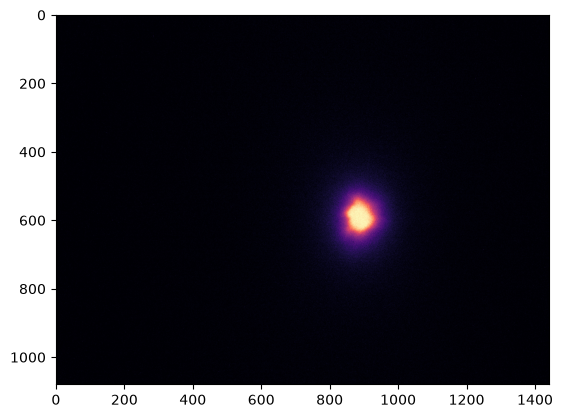

In [170]:
img_it = 10
bg_it = 2

exp.set_iterations(bg_it)
motcam.setup_acquisition(nframes=bg_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": rep_vco_mot, "tMOTLoadCoolVCO": cool_vco_mot, "tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1000, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000})
imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

exp.set_iterations(img_it)
motcam.setup_acquisition(nframes=img_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": rep_vco_mot, "tMOTLoadCoolVCO": cool_vco_mot, "tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1000, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000})
imgs = motcam.acquire_n_frames(nframes=img_it)
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)

plt.imshow(img_mean, cmap='magma', vmin=0)

### Find MOT Centre

In [103]:
# Get centre of MOT
img_it = 10
bg_it = 2
exp.set_iterations(bg_it)
motcam.setup_acquisition(nframes=bg_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVCO1": 4.5, "tImgCoolVVA1": 4.0, "tImgRepVCO1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0})
imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

exp.set_iterations(img_it)
motcam.setup_acquisition(nframes=img_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVCO1": 4.5, "tImgCoolVVA1": 4.0, "tImgRepVCO1": 4.0, "tImgRepVVA1": 4.0})
imgs = motcam.acquire_n_frames(nframes=img_it)
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)

try:
    gaussian_params = fit_gaussian(img_mean)
    centre_x, centre_y = int(gaussian_params["x0"]), int(gaussian_params["y0"])
    print(f"MOT detected at (x, y): ({centre_x}, {centre_y})")
except Exception as e:
    print("Could not detect MOT.")

MOT detected at (x, y): (283, 276)


### Find Resonances

Cooling VCO resonance: 4.7368421052631575


Text(0, 0.5, 'Total Counts (a.u.)')

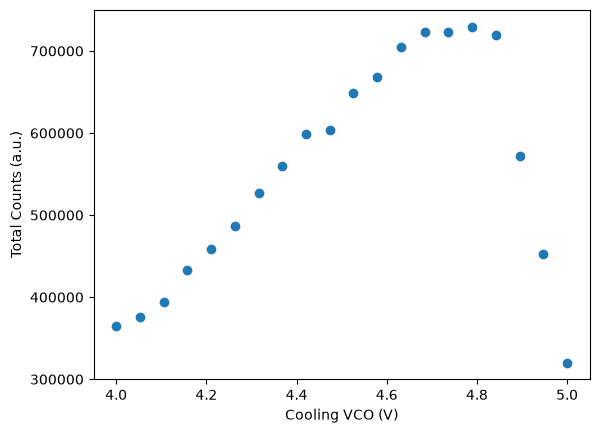

In [104]:
from scipy.signal import savgol_filter

img_it = 10
bg_it = 2

VCOList = np.linspace(4.0, 5.0, 20)
counts = []

print(f"Scanning imaging repump VCO...")
for vco in VCOList:
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tImgCoolVCO1": vco, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVCO1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tcMOTccValue": 0.0})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tImgCoolVCO1": vco, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVCO1": 4.0, "tImgRepVVA1": 4.0})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    total_counts = get_total_counts(img_mean, centre_x, centre_y, window_size=50)
    counts.append(total_counts)

counts_smooth = savgol_filter(counts, 3, 1)  # window size 11, polynomial order 3
max_index = np.argmax(counts_smooth)
cool_vco_resonance = VCOList[max_index]
print(f"Cooling VCO resonance: {cool_vco_resonance}")

plt.scatter(VCOList, counts)
plt.xlabel("Cooling VCO (V)")
plt.ylabel("Total Counts (a.u.)")

Repump VCO resonance: 5.0


Text(0, 0.5, 'Total Counts (a.u.)')

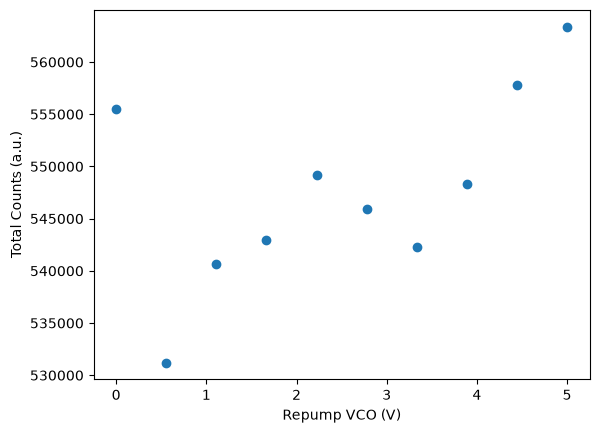

In [112]:
from scipy.signal import savgol_filter

img_it = 10
bg_it = 2

VCOList = np.linspace(0.0, 5.0, 10)
counts = []

print(f"Scanning imaging repump VCO...")
for vco in VCOList:
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tImgRepVCO1": vco, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tcMOTccValue": 0.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 30000})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tImgRepVCO1": vco, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 30000})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    total_counts = get_total_counts(img_mean, centre_x, centre_y, window_size=50)
    counts.append(total_counts)
    
counts_smooth = savgol_filter(counts, 3, 1)  # window size 11, polynomial order 3
max_index = np.argmax(counts_smooth)
rep_vco_resonance = VCOList[max_index]
print(f"Repump VCO resonance: {rep_vco_resonance}")
plt.scatter(VCOList, counts, label='Raw Counts')
plt.xlabel("Repump VCO (V)")
plt.ylabel("Total Counts (a.u.)")

### MOT Number

Cooling VCO MOT resonance: 4.2631578947368425


Text(0, 0.5, 'Total Counts (a.u.)')

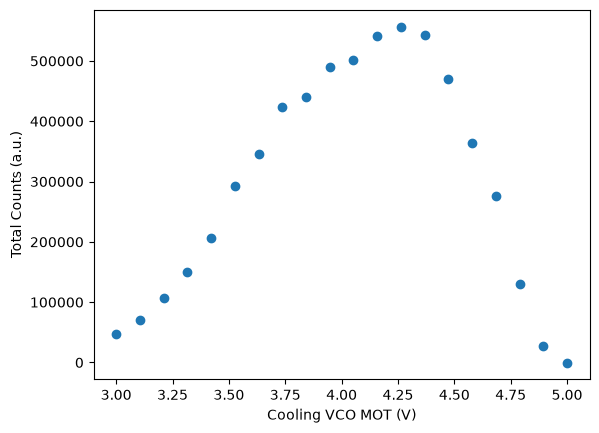

In [113]:
from scipy.signal import savgol_filter

img_it = 10
bg_it = 2

VCOList = np.linspace(3.0, 5.0, 20)
counts = []

print(f"Scanning MOT cooling VCO...")
for vco in VCOList:
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadCoolVCO": vco, "tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tcMOTccValue": 0.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 30000})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadCoolVCO": vco,"tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 30000})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    total_counts = get_total_counts(img_mean, centre_x, centre_y, window_size=50)
    counts.append(total_counts)

counts_smooth = savgol_filter(counts, 3, 1)  # window size 11, polynomial order 3
max_index = np.argmax(counts_smooth)
cool_vco_mot = VCOList[max_index]
print(f"Cooling VCO MOT resonance: {cool_vco_mot}")
plt.scatter(VCOList, counts, label='Raw Counts')
plt.xlabel("Cooling VCO MOT (V)")
plt.ylabel("Total Counts (a.u.)")

Repump VCO MOT resonance: 1.5789473684210527


Text(0, 0.5, 'Total Counts (a.u.)')

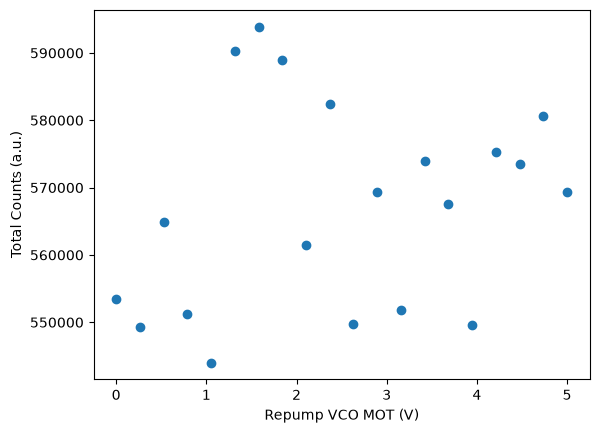

In [115]:
from scipy.signal import savgol_filter

img_it = 10
bg_it = 2

VCOList = np.linspace(0.0, 5.0, 20)
counts = []

print(f"Scanning MOT repump VCO...")
for vco in VCOList:
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": vco, "tMOTLoadCoolVCO": cool_vco_mot, "tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 30000})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": vco, "tMOTLoadCoolVCO": cool_vco_mot,"tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 30000})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    total_counts = get_total_counts(img_mean, centre_x, centre_y, window_size=50)
    counts.append(total_counts)

counts_smooth = savgol_filter(counts, 3, 1)  # window size 11, polynomial order 3
max_index = np.argmax(counts_smooth)
rep_vco_mot = VCOList[max_index]
print(f"Repump VCO MOT resonance: {rep_vco_mot}")
plt.scatter(VCOList, counts, label='Raw Counts')
plt.xlabel("Repump VCO MOT (V)")
plt.ylabel("Total Counts (a.u.)")

### MOT/Molasses Temp

In [186]:
n_it = 20
img_it = 5
bg_it = 2

tau_list = np.arange(1, 1000, 1000/n_it)
images = []

print(f"Running TOF temperature measurement...")
for it, tau in enumerate(tau_list):
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": rep_vco_mot, "tMOTLoadCoolVCO": cool_vco_mot, "tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": int(tau), "tMolassesDuration": 1000, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000 + int(tau)})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": rep_vco_mot, "tMOTLoadCoolVCO": cool_vco_mot,"tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": int(tau), "tMolassesDuration": 1000, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000 + int(tau)})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    images.append(img_mean)
    print(f"Iteration {str(it+1).zfill(2)}/{n_it}  |  TOF: {tau/100:.2f} ms")

Running TOF temperature measurement...
Iteration 1/20  |  TOF: 0.01 ms
Iteration 2/20  |  TOF: 0.51 ms
Iteration 3/20  |  TOF: 1.01 ms
Iteration 4/20  |  TOF: 1.51 ms
Iteration 5/20  |  TOF: 2.01 ms
Iteration 6/20  |  TOF: 2.51 ms
Iteration 7/20  |  TOF: 3.01 ms
Iteration 8/20  |  TOF: 3.51 ms
Iteration 9/20  |  TOF: 4.01 ms
Iteration 10/20  |  TOF: 4.51 ms
Iteration 11/20  |  TOF: 5.01 ms
Iteration 12/20  |  TOF: 5.51 ms
Iteration 13/20  |  TOF: 6.01 ms
Iteration 14/20  |  TOF: 6.51 ms
Iteration 15/20  |  TOF: 7.01 ms
Iteration 16/20  |  TOF: 7.51 ms
Iteration 17/20  |  TOF: 8.01 ms
Iteration 18/20  |  TOF: 8.51 ms
Iteration 19/20  |  TOF: 9.01 ms
Iteration 20/20  |  TOF: 9.51 ms


Extracting Gaussian fit parameters...
Iteration 01/20  |  TOF: 0.01 ms  |  Amplitude: 1049.43  |  Centre: (888, 586)  |  Widths: (sx: 53.116, sy: 42.584)
Iteration 02/20  |  TOF: 0.51 ms  |  Amplitude: 1042.34  |  Centre: (890, 589)  |  Widths: (sx: 53.2458, sy: 44.5004)
Iteration 03/20  |  TOF: 1.01 ms  |  Amplitude: 1036.33  |  Centre: (891, 590)  |  Widths: (sx: 54.1554, sy: 44.4593)
Iteration 04/20  |  TOF: 1.51 ms  |  Amplitude: 990.476  |  Centre: (891, 590)  |  Widths: (sx: 56.6108, sy: 47.13)
Iteration 05/20  |  TOF: 2.01 ms  |  Amplitude: 970.427  |  Centre: (893, 588)  |  Widths: (sx: 56.7016, sy: 48.5769)
Iteration 06/20  |  TOF: 2.51 ms  |  Amplitude: 890.738  |  Centre: (894, 593)  |  Widths: (sx: 61.0525, sy: 51.2515)
Iteration 07/20  |  TOF: 3.01 ms  |  Amplitude: 812.669  |  Centre: (893, 590)  |  Widths: (sx: 63.7604, sy: 54.2284)
Iteration 08/20  |  TOF: 3.51 ms  |  Amplitude: 708.292  |  Centre: (900, 592)  |  Widths: (sx: 68.1997, sy: 58.7133)
Iteration 09/20  |  TO

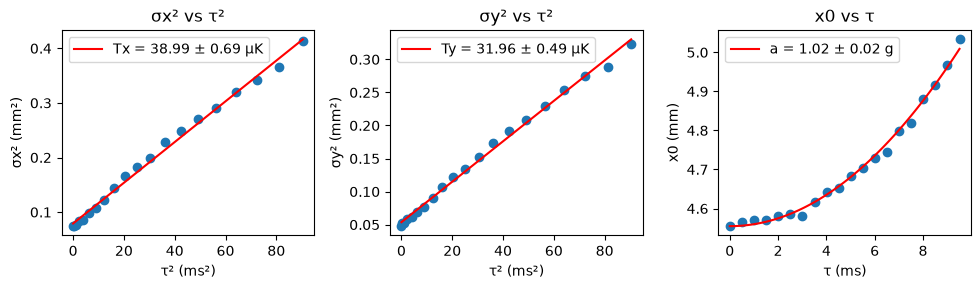

In [187]:
print(f"Extracting Gaussian fit parameters...")
x0_list, y0_list, sx_list, sy_list = [], [], [], []
for it, img in enumerate(images):
    gaussian_params = fit_gaussian(img)
    amp, centre_x, centre_y, sx, sy = gaussian_params["A"], int(gaussian_params["x0"]), int(gaussian_params["y0"]), gaussian_params["sx"], gaussian_params["sy"]
    print(f"Iteration {str(it+1).zfill(2)}/{n_it}  |  TOF: {tau_list[it]/100:.6g} ms  |  Amplitude: {amp:.6g}  |  Centre: ({centre_x}, {centre_y})  |  Widths: (sx: {sx:.6g}, sy: {sy:.6g})")
    x0_list.append(centre_x)
    y0_list.append(centre_y)
    sx_list.append(sx)
    sy_list.append(sy)

tau_list_ms = tau_list * 1 / 100
tau_list_s = tau_list_ms * 1 / 1000
sx_array = np.array(sx_list) * gamma
sy_array = np.array(sy_list) * gamma
x0_array = np.array(x0_list) * gamma
y0_array = np.array(y0_list) * gamma

lin_fit = lambda x, m, c: m * x + c
px, pcovx = curve_fit(lin_fit, tau_list_ms**2, sx_array**2)
py, pcovy = curve_fit(lin_fit, tau_list_ms**2, sy_array**2)
t2_fit = np.linspace(0, tau_list_ms[-1]**2, 100)
sx2_fit = lin_fit(t2_fit, *px)
sy2_fit = lin_fit(t2_fit, *py)
mx = px[0]  # slope for sx^2 vs tau^2
my = py[0]  # slope for sy^2 vs tau^2
Tx = mx * MRb / kB * 1e6
Ty = my * MRb / kB * 1e6
mx_err = np.sqrt(np.diag(pcovx))[0]
my_err = np.sqrt(np.diag(pcovy))[0]
Tx_err = mx_err * MRb / kB * 1e6
Ty_err = my_err * MRb / kB * 1e6

free_fall = lambda t, a, x0: 1/2 * a * t**2 + x0
param1, pcov1 = curve_fit(free_fall, tau_list_ms, x0_array)
t_fit = np.linspace(0, tau_list_ms[-1], 100)
x0_fit = free_fall(t_fit, *param1)
a = param1[0] # acceleration in pixels/ms²
a_err = np.sqrt(np.diag(pcov1))[0]

# Plot sx_array, sy_array, x0_array all three side by side with respect to tau_list_ms
plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.scatter(tau_list_ms**2, sx_array**2)
plt.plot(t2_fit, sx2_fit, color='red', label=f"Tx = {Tx:.2f} ± {Tx_err:.2f} μK")
plt.legend()
plt.xlabel('τ² (ms²)')
plt.ylabel('σx² (mm²)')
plt.title('σx² vs τ²')

plt.subplot(1, 3, 2)
plt.scatter(tau_list_ms**2, sy_array**2)
plt.plot(t2_fit, sy2_fit, color='red', label=f"Ty = {Ty:.2f} ± {Ty_err:.2f} μK")
plt.legend()
plt.xlabel('τ² (ms²)')
plt.ylabel('σy² (mm²)')
plt.title('σy² vs τ²')

plt.subplot(1, 3, 3)
plt.scatter(tau_list_ms, x0_array)
plt.plot(t_fit, x0_fit, color='red', label=f"a = {a/(9.81/1000):.2f} ± {a_err/(9.81/1000):.2f} g")
plt.legend()
plt.xlabel('τ (ms)')
plt.ylabel('x0 (mm)')
plt.title('x0 vs τ')

plt.tight_layout()
plt.show()

In [188]:
n_it = 3
img_it = 10
bg_it = 2

tau_list = np.arange(200, 1000, 1000/n_it)
images = []

print(f"Running TOF temperature measurement...")
for it, tau in enumerate(tau_list):
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": rep_vco_mot, "tMOTLoadCoolVCO": cool_vco_mot, "tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": int(tau), "tMolassesDuration": 1000, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000 + int(tau)})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": rep_vco_mot, "tMOTLoadCoolVCO": cool_vco_mot,"tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": int(tau), "tMolassesDuration": 1000, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000 + int(tau)})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    images.append(img_mean)
    print(f"Iteration {it+1}/{n_it}  |  TOF: {tau/100:.2f} ms")

Running TOF temperature measurement...
Iteration 01/3  |  TOF: 2.00 ms
Iteration 02/3  |  TOF: 5.33 ms
Iteration 03/3  |  TOF: 8.67 ms


Extracting Gaussian fit parameters...
Iteration 01/3  |  TOF: 2 ms  |  Amplitude: 969.489  |  Centre: (891, 587)  |  Widths: (sx: 58.683, sy: 48.6707)
Iteration 02/3  |  TOF: 5.33333 ms  |  Amplitude: 515.168  |  Centre: (916, 590)  |  Widths: (sx: 84.3072, sy: 72.8524)
Iteration 03/3  |  TOF: 8.66667 ms  |  Amplitude: 282.881  |  Centre: (961, 595)  |  Widths: (sx: 115.781, sy: 103.203)


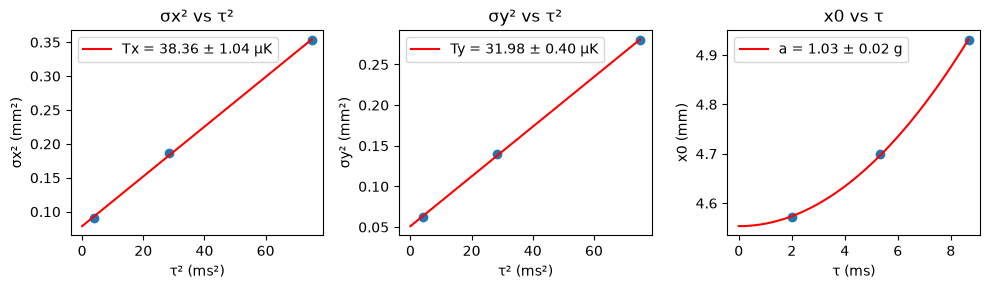

In [189]:
print(f"Extracting Gaussian fit parameters...")
x0_list, y0_list, sx_list, sy_list = [], [], [], []
for it, img in enumerate(images):
    gaussian_params = fit_gaussian(img)
    amp, centre_x, centre_y, sx, sy = gaussian_params["A"], int(gaussian_params["x0"]), int(gaussian_params["y0"]), gaussian_params["sx"], gaussian_params["sy"]
    print(f"Iteration {it+12}/{n_it}  |  TOF: {tau_list[it]/100:.6g} ms  |  Amplitude: {amp:.6g}  |  Centre: ({centre_x}, {centre_y})  |  Widths: (sx: {sx:.6g}, sy: {sy:.6g})")
    x0_list.append(centre_x)
    y0_list.append(centre_y)
    sx_list.append(sx)
    sy_list.append(sy)

tau_list_ms = tau_list * 1 / 100
tau_list_s = tau_list_ms * 1 / 1000
sx_array = np.array(sx_list) * gamma
sy_array = np.array(sy_list) * gamma
x0_array = np.array(x0_list) * gamma
y0_array = np.array(y0_list) * gamma

lin_fit = lambda x, m, c: m * x + c
px, pcovx = curve_fit(lin_fit, tau_list_ms**2, sx_array**2)
py, pcovy = curve_fit(lin_fit, tau_list_ms**2, sy_array**2)
t2_fit = np.linspace(0, tau_list_ms[-1]**2, 100)
sx2_fit = lin_fit(t2_fit, *px)
sy2_fit = lin_fit(t2_fit, *py)
mx = px[0]  # slope for sx^2 vs tau^2
my = py[0]  # slope for sy^2 vs tau^2
Tx = mx * MRb / kB * 1e6
Ty = my * MRb / kB * 1e6
mx_err = np.sqrt(np.diag(pcovx))[0]
my_err = np.sqrt(np.diag(pcovy))[0]
Tx_err = mx_err * MRb / kB * 1e6
Ty_err = my_err * MRb / kB * 1e6

free_fall = lambda t, a, x0: 1/2 * a * t**2 + x0
param1, pcov1 = curve_fit(free_fall, tau_list_ms, x0_array)
t_fit = np.linspace(0, tau_list_ms[-1], 100)
x0_fit = free_fall(t_fit, *param1)
a = param1[0] # acceleration in pixels/ms²
a_err = np.sqrt(np.diag(pcov1))[0]

# Plot sx_array, sy_array, x0_array all three side by side with respect to tau_list_ms
plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.scatter(tau_list_ms**2, sx_array**2)
plt.plot(t2_fit, sx2_fit, color='red', label=f"Tx = {Tx:.2f} ± {Tx_err:.2f} μK")
plt.legend()
plt.xlabel('τ² (ms²)')
plt.ylabel('σx² (mm²)')
plt.title('σx² vs τ²')

plt.subplot(1, 3, 2)
plt.scatter(tau_list_ms**2, sy_array**2)
plt.plot(t2_fit, sy2_fit, color='red', label=f"Ty = {Ty:.2f} ± {Ty_err:.2f} μK")
plt.legend()
plt.xlabel('τ² (ms²)')
plt.ylabel('σy² (mm²)')
plt.title('σy² vs τ²')

plt.subplot(1, 3, 3)
plt.scatter(tau_list_ms, x0_array)
plt.plot(t_fit, x0_fit, color='red', label=f"a = {a/(9.81/1000):.2f} ± {a_err/(9.81/1000):.2f} g")
plt.legend()
plt.xlabel('τ (ms)')
plt.ylabel('x0 (mm)')
plt.title('x0 vs τ')

plt.tight_layout()
plt.show()

In [196]:
from pytweezer.experiment.experimental_parameters import DefaultExperimentalParameters

ExpParams = DefaultExperimentalParameters()
cooling_resonance = ExpParams.get_parameter("cool_vco_resonance")
cooling_resonance

4.7368421052631575

## Tweezer Optimisation

In [1]:
from pytweezer.drivers.slm import SLM
slm : SLM = SLM()

SLM 1 initialised: 1024x1024 @ 8-bit, serial 7752, 40.169 degC
SLM 1 loaded LUT "C:\Program Files\Meadowlark Optics\Blink Plus\LUT Files\slm40_at852.LUT"


In [5]:
import pytweezer.phasemask as pm

dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

W1 = np.ones((15, 15))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um
--- Target Generation ---
Grid: 15x15
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 3.93e-06 | Uniformity: 40.45% | Min/Max ratio: 0.040
Iteration 010 | Mean-Squared Error: 2.57e-08 | Uniformity: 75.63% | Min/Max ratio: 0.354
Iteration 020 | Mean-Squared Error: 7.47e-09 | Uniformity: 75.89% | Min/Max ratio: 0.378
Iteration 030 | Mean-Squared Error: 2.73e-09 | Uniformity: 75.84% | Min/Max ratio: 0.384
Iteration 040 | Mean-Squared Error: 1.95e-09 | Uniformity: 76.04% | Min/Max ratio: 0.385
Iteration 050 | Mean-Squared Error: 6.45e-10 | Uniformity: 76.07% | Min/Max ratio: 0.386
Iteration 060 | Mean-Squared Er

In [7]:
from pytweezer.drivers.imagemX2 import ImagEMX2Camera

hamcam : ImagEMX2Camera = ImagEMX2Camera()

ImagEM X2 camera initialised.


In [202]:
from pytweezer import analysis as pyt

texp = pyt.TweezerExperimentAnalysis(day='26',month='05May', year='2026')

---- 26/05May/202026 Tweezer Experiment Analysis Initialised ----


In [200]:
hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(1200)
hamcam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 110, 220, 256, 256
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

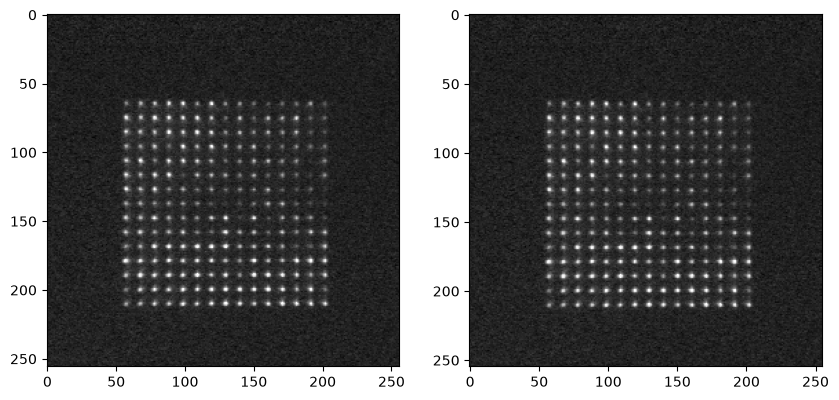

In [235]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadCoolVCO": ExpParams.get_parameter("cool_vco_mot"), "tMOTLoadRepVCO": ExpParams.get_parameter("rep_vco_mot")})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = texp.tweezer_show_bg_subtracted(imgs1, imgs2, reg=[0, -1, 0, -1], cmap='gray', show=True, vmaxfactor=0.6, show_grid=True)

Looking for trap sites...
15x15 array detected.


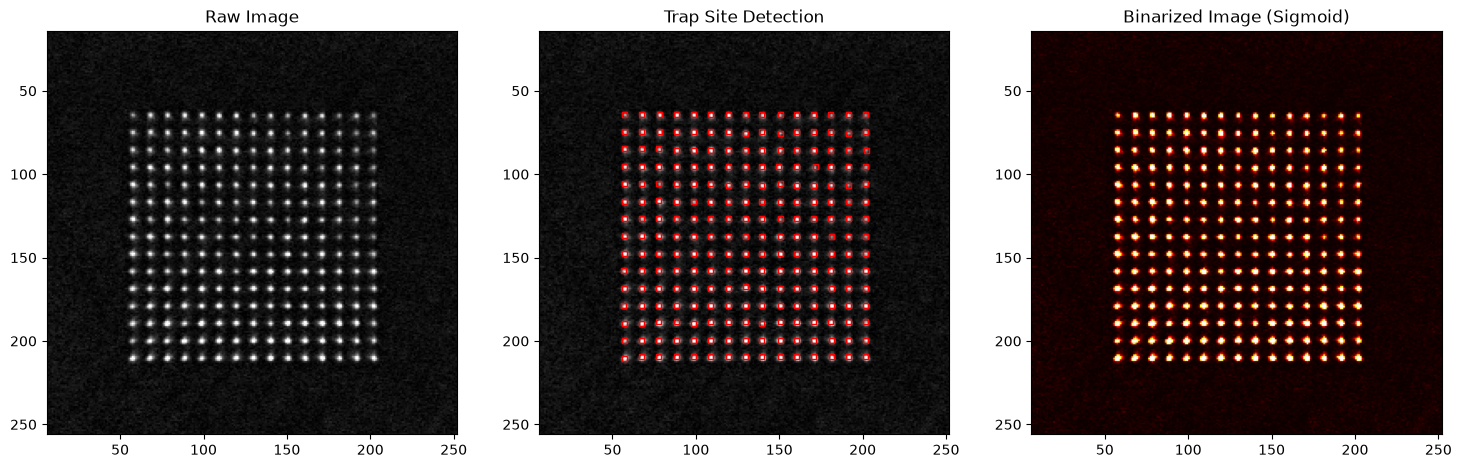

Trap (0, 0) Loading Probability : 34.00 %
Trap (0, 1) Loading Probability : 54.00 %
Trap (0, 2) Loading Probability : 49.00 %
Trap (0, 3) Loading Probability : 52.00 %
Trap (0, 4) Loading Probability : 49.00 %
Trap (0, 5) Loading Probability : 48.00 %
Trap (0, 6) Loading Probability : 49.00 %
Trap (0, 7) Loading Probability : 32.00 %
Trap (0, 8) Loading Probability : 43.00 %
Trap (0, 9) Loading Probability : 32.00 %
Trap (0, 10) Loading Probability : 47.00 %
Trap (0, 11) Loading Probability : 48.00 %
Trap (0, 12) Loading Probability : 31.00 %
Trap (0, 13) Loading Probability : 47.00 %
Trap (0, 14) Loading Probability : 38.00 %
Trap (1, 0) Loading Probability : 45.00 %
Trap (1, 1) Loading Probability : 51.00 %
Trap (1, 2) Loading Probability : 52.00 %
Trap (1, 3) Loading Probability : 45.00 %
Trap (1, 4) Loading Probability : 51.00 %
Trap (1, 5) Loading Probability : 44.00 %
Trap (1, 6) Loading Probability : 57.00 %
Trap (1, 7) Loading Probability : 46.00 %
Trap (1, 8) Loading Probabili

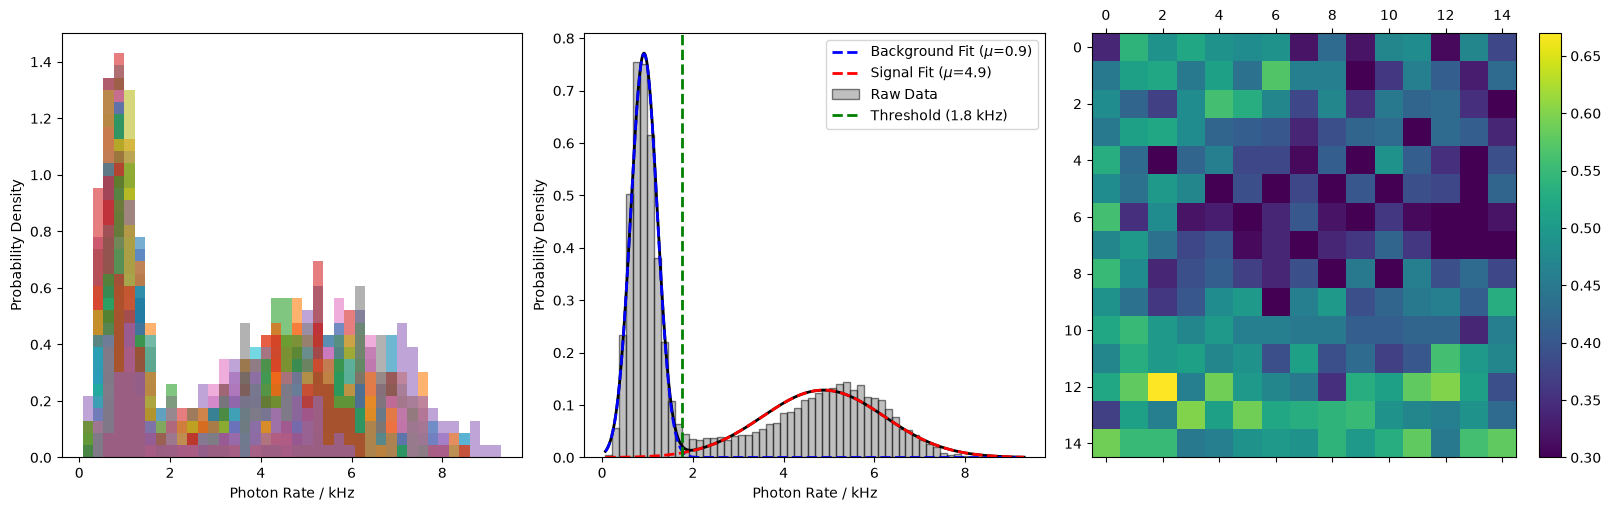

In [234]:
array_shape = [15, 15]
window = 3
feature_size = 10

filtered_img_average = pyt.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions, detection_threshold = pyt.detect_trap_sites(filtered_img_average, array_shape, detection_step=100)
pyt.visualize_results(filtered_img_average, grid_positions, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates, loading_probabilities, threshold, fidelity = texp.get_array_loading_statistics(imgs_filtered, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60)

---

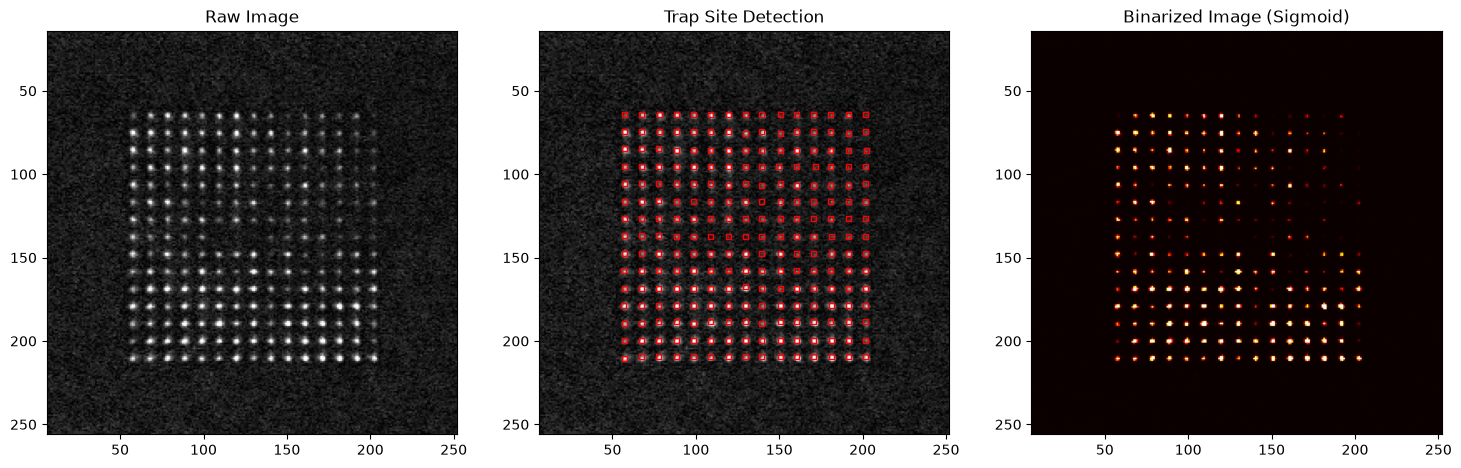

Trap (0, 0) Loading Probability : 13.00 %
Trap (0, 1) Loading Probability : 24.00 %
Trap (0, 2) Loading Probability : 30.00 %
Trap (0, 3) Loading Probability : 22.00 %
Trap (0, 4) Loading Probability : 17.00 %
Trap (0, 5) Loading Probability : 20.00 %
Trap (0, 6) Loading Probability : 29.00 %
Trap (0, 7) Loading Probability : 14.00 %
Trap (0, 8) Loading Probability : 13.00 %
Trap (0, 9) Loading Probability : 4.00 %
Trap (0, 10) Loading Probability : 12.00 %
Trap (0, 11) Loading Probability : 15.00 %
Trap (0, 12) Loading Probability : 10.00 %
Trap (0, 13) Loading Probability : 19.00 %
Trap (0, 14) Loading Probability : 8.00 %
Trap (1, 0) Loading Probability : 36.00 %
Trap (1, 1) Loading Probability : 33.00 %
Trap (1, 2) Loading Probability : 21.00 %
Trap (1, 3) Loading Probability : 24.00 %
Trap (1, 4) Loading Probability : 18.00 %
Trap (1, 5) Loading Probability : 21.00 %
Trap (1, 6) Loading Probability : 28.00 %
Trap (1, 7) Loading Probability : 17.00 %
Trap (1, 8) Loading Probability

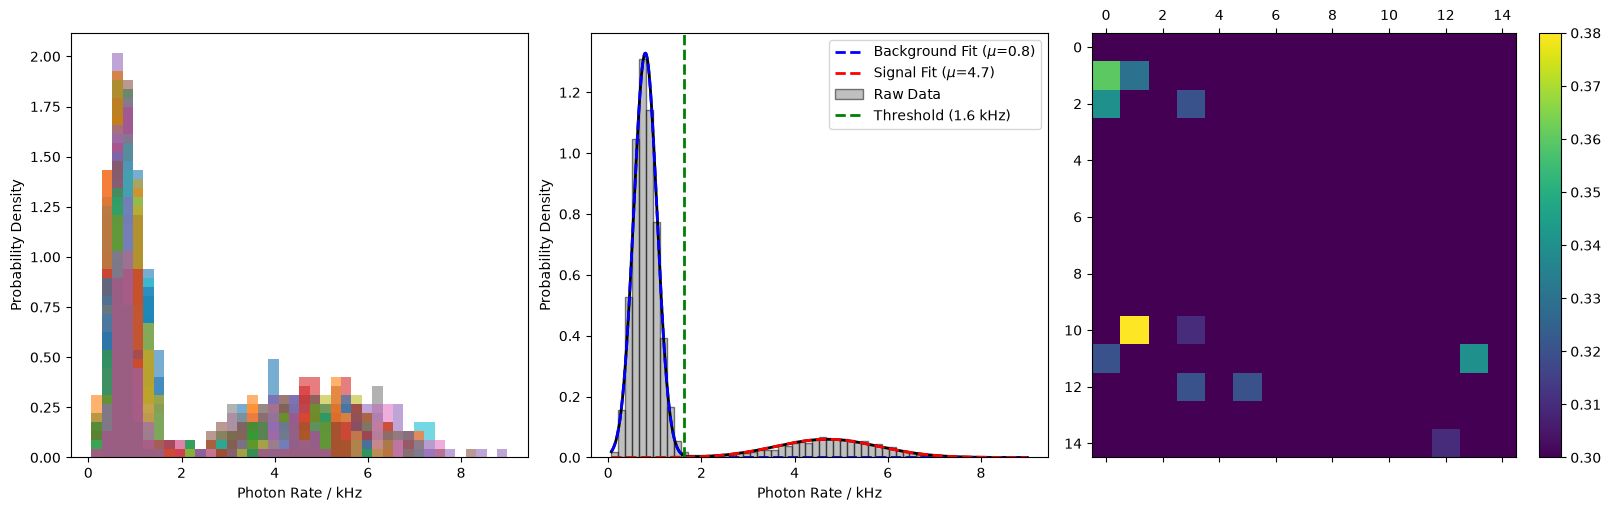

In [240]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadCoolVCO": ExpParams.get_parameter("cool_vco_mot"), "tMOTLoadRepVCO": ExpParams.get_parameter("rep_vco_mot")})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = texp.tweezer_show_bg_subtracted(imgs1, imgs2, reg=[0, -1, 0, -1], cmap='gray', show=False, vmaxfactor=0.6, show_grid=True)

array_shape = [15, 15]
window = 3
feature_size = 10

filtered_img_average = pyt.morphological_tophat_high_pass(img_average, feature_size=feature_size)
pyt.visualize_results(filtered_img_average, grid_positions, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates, loading_probabilities, threshold, fidelity = texp.get_array_loading_statistics(imgs_filtered, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60)

### Bayesian Optimisation of Molasses Parameters

In [243]:
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt import Optimizer
from skopt.plots import plot_convergence

ImportError: cannot import name 'DOUBLE' from 'sklearn.tree._tree' (c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\sklearn\tree\_tree.cp311-win_amd64.pyd)

In [7]:
slm.close()
hamcam.close()
motcam.close()


SLM 1 closed.


NameError: name 'hamcam' is not defined